In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = "suicides2024.xlsx"

xls = pd.ExcelFile(file)

print("Total Sheets:", len(xls.sheet_names))
print(xls.sheet_names)

Total Sheets: 17
['Cover_sheet', 'Table_of_contents', 'Guidance', 'Notes', 'Table_1', 'Table_2', 'Table_3', 'Table_4', 'Table_5', 'Table_6', 'Table_7', 'Table_8', 'Table_9', 'Table_10', 'Table_11', 'Table_12', 'Table_13']


# Check All Tables

In [2]:
for sheet in xls.sheet_names:

    df = pd.read_excel(file, sheet_name=sheet)

    print("\n" + "="*60)
    print("Sheet:", sheet)
    print("Shape:", df.shape)


Sheet: Cover_sheet
Shape: (68, 1)

Sheet: Table_of_contents
Shape: (18, 2)

Sheet: Guidance
Shape: (66, 4)

Sheet: Notes
Shape: (28, 3)

Sheet: Table_1
Shape: (48, 15)

Sheet: Table_2
Shape: (48, 15)

Sheet: Table_3
Shape: (48, 15)

Sheet: Table_4
Shape: (31, 179)

Sheet: Table_5
Shape: (136, 89)

Sheet: Table_6
Shape: (136, 89)

Sheet: Table_7
Shape: (136, 89)

Sheet: Table_8
Shape: (137, 24)

Sheet: Table_9
Shape: (84, 25)

Sheet: Table_10
Shape: (40, 99)

Sheet: Table_11
Shape: (75, 8)

Sheet: Table_12
Shape: (28, 24)

Sheet: Table_13
Shape: (29, 29)


# Best Sheet for Analysis

In [3]:
for sheet in [
    "Table_1",
    "Table_2",
    "Table_3",
    "Table_4",
    "Table_5",
    "Table_6",
    "Table_7",
    "Table_8",
    "Table_9",
    "Table_10",
    "Table_11",
    "Table_12",
    "Table_13"
]:

    df = pd.read_excel(file, sheet_name=sheet)

    print("\n")
    print(sheet)

    print(df.head(5))



Table_1
  Table 1: Age-standardised suicide [note 1] rates per 100,000 population by sex, England and Wales, 1981 to 2024 registrations  \
0                 This worksheet contains one table.                                                                              
1  Some cells refer to notes which can be found o...                                                                              
2  LCL = lower confidence limit (95%) and UCL = u...                                                                              
3                               Area code \n[note 2]                                                                              
4                                          K04000001                                                                              

                           Unnamed: 1                             Unnamed: 2  \
0                                 NaN                                    NaN   
1                                 NaN      

In [4]:
df = pd.read_excel(
    "suicides2024.xlsx",
    sheet_name="Table_1"
)

print(df.head(20))
print(df.columns.tolist())
print(df.shape)

   Table 1: Age-standardised suicide [note 1] rates per 100,000 population by sex, England and Wales, 1981 to 2024 registrations  \
0                  This worksheet contains one table.                                                                              
1   Some cells refer to notes which can be found o...                                                                              
2   LCL = lower confidence limit (95%) and UCL = u...                                                                              
3                                Area code \n[note 2]                                                                              
4                                           K04000001                                                                              
5                                           K04000001                                                                              
6                                           K04000001                       

In [5]:
df = pd.read_excel(
    "suicides2024.xlsx",
    sheet_name="Table_4"
)

print(df.head(20))
print(df.columns.tolist())
print(df.shape)

   Table 4: Age-standardised suicide [note 1] rates per 100,000 population by sex, regions of England, 1981 to 2024 registrations  \
0                  This worksheet contains one table.                                                                               
1   Some cells refer to notes which can be found o...                                                                               
2   LCL = lower confidence limit (95%) and UCL = u...                                                                               
3                                                 Sex                                                                               
4                                             Persons                                                                               
5                                             Persons                                                                               
6                                             Persons                

# CLEAN TABLE 1

In [6]:
raw1 = pd.read_excel(
    file,
    sheet_name="Table_1",
    header=None
)

trend = raw1.iloc[4:].copy()

trend = trend[
    [2,3,4,7,8,11,12]
]

trend.columns = [
    "Year",
    "Persons_Deaths",
    "Persons_Rate",
    "Male_Deaths",
    "Male_Rate",
    "Female_Deaths",
    "Female_Rate"
]

for col in trend.columns:

    trend[col] = pd.to_numeric(
        trend[col],
        errors="coerce"
    )

trend = trend.dropna()

trend.head()

,Year,Persons_Deaths,Persons_Rate,Male_Deaths,Male_Rate,Female_Deaths,Female_Rate
5,2024.0,6190.0,11.4,4599.0,17.6,1591.0,5.7
6,2023.0,6069.0,11.3,4506.0,17.4,1563.0,5.7
7,2022.0,5642.0,10.7,4179.0,16.4,1463.0,5.4
8,2021.0,5583.0,10.7,4129.0,16.2,1454.0,5.4
9,2020.0,5224.0,10.0,3925.0,15.5,1299.0,4.8


# EDA

In [7]:
print(trend.shape)

(44, 7)


# Missing Values

In [8]:
print(
    trend.isnull().sum()
)

Year              0
Persons_Deaths    0
Persons_Rate      0
Male_Deaths       0
Male_Rate         0
Female_Deaths     0
Female_Rate       0
dtype: int64


# Data Types

In [9]:
print(
    trend.dtypes
)

Year              float64
Persons_Deaths    float64
Persons_Rate      float64
Male_Deaths       float64
Male_Rate         float64
Female_Deaths     float64
Female_Rate       float64
dtype: object


# Summary Statistics

In [10]:
print(
    trend.describe()
)

              Year  Persons_Deaths  Persons_Rate  Male_Deaths  Male_Rate  \
count    44.000000       44.000000     44.000000    44.000000  44.000000   
mean   2002.500000     5214.068182     11.284091  3809.250000  17.088636   
std      12.845233      443.614247      1.563678   288.472491   1.743455   
min    1981.000000     4313.000000      9.000000  3301.000000  14.200000   
25%    1991.750000     4878.500000     10.225000  3575.250000  15.750000   
50%    2002.500000     5184.000000     10.800000  3779.500000  16.900000   
75%    2013.250000     5545.500000     12.425000  4026.750000  18.500000   
max    2024.000000     6190.000000     14.500000  4599.000000  20.900000   

       Female_Deaths  Female_Rate  
count      44.000000    44.000000  
mean     1404.818182     6.002273  
std       298.560132     1.724446  
min      1012.000000     4.200000  
25%      1216.250000     4.800000  
50%      1298.000000     5.450000  
75%      1500.750000     6.425000  
max      2178.000000    10.

# CRISIS TREND CHART

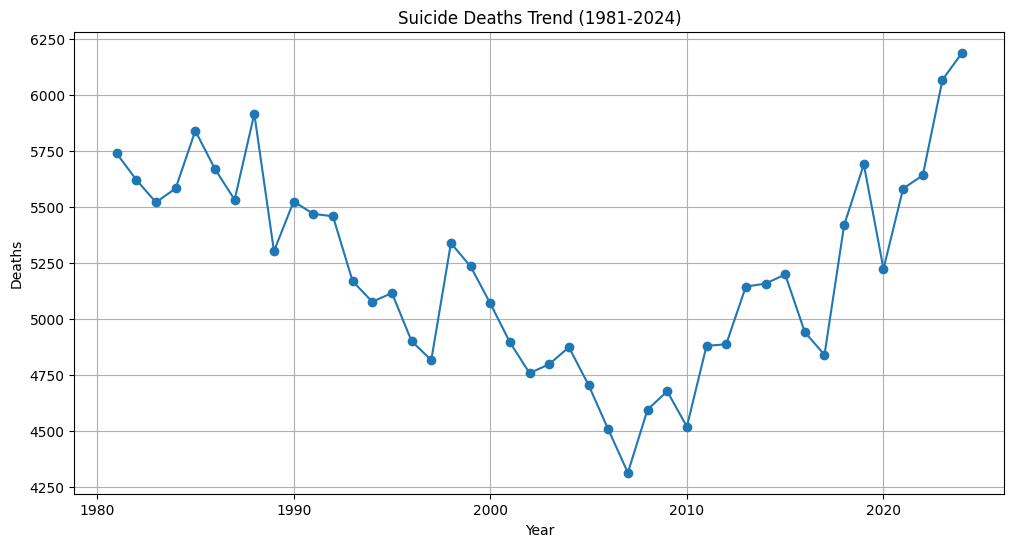

In [11]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    trend["Year"],
    trend["Persons_Deaths"],
    marker="o"
)

plt.title(
    "Suicide Deaths Trend (1981-2024)"
)

plt.xlabel("Year")
plt.ylabel("Deaths")

plt.grid()

plt.show()

# MALE VS FEMALE

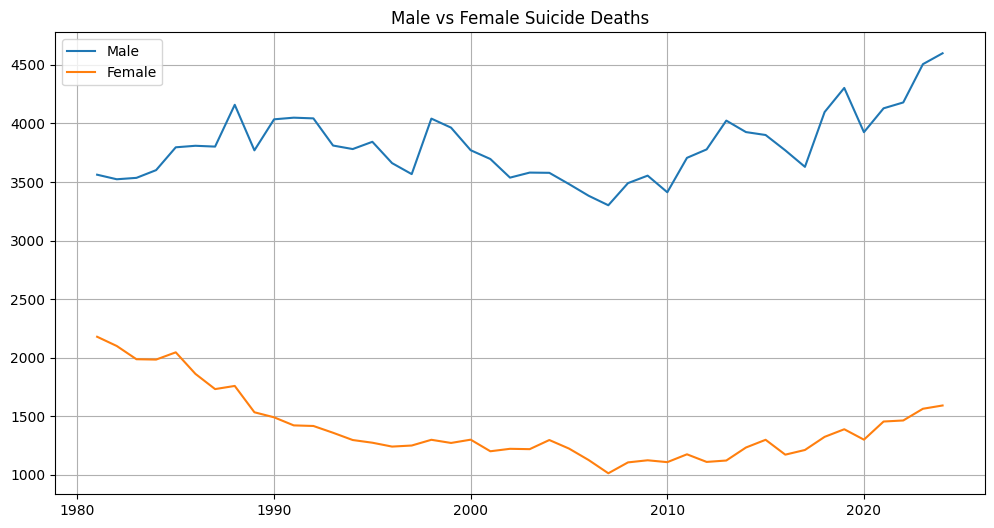

In [12]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    trend["Year"],
    trend["Male_Deaths"],
    label="Male"
)

plt.plot(
    trend["Year"],
    trend["Female_Deaths"],
    label="Female"
)

plt.title(
    "Male vs Female Suicide Deaths"
)

plt.legend()

plt.grid()

plt.show()

# SUICIDE RATE TREND

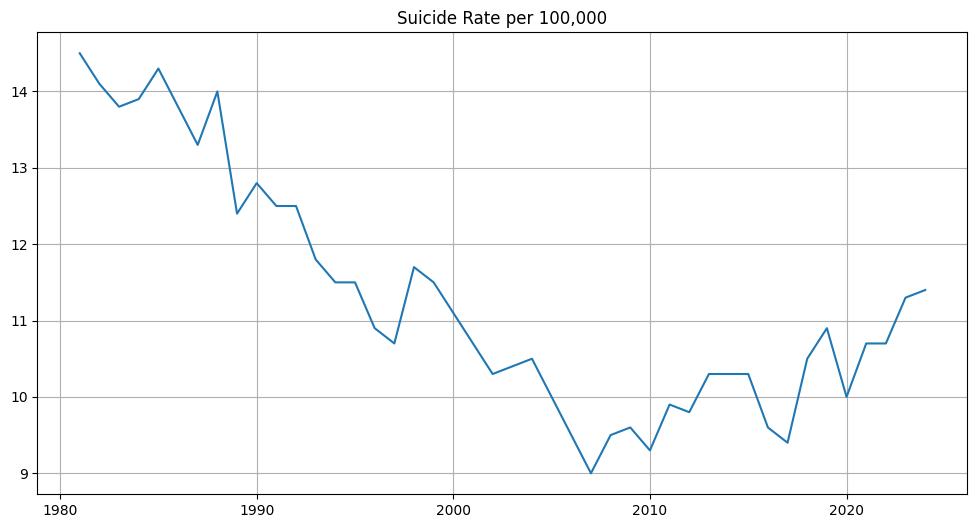

In [13]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    trend["Year"],
    trend["Persons_Rate"]
)

plt.title(
    "Suicide Rate per 100,000"
)

plt.grid()

plt.show()

# REGIONAL ANALYSIS (TABLE 4)

In [14]:
raw4 = pd.read_excel(
    file,
    sheet_name="Table_4",
    header=None
)

regions = raw4.iloc[5:14].copy()

regions = regions[[2, 3, 4]]

regions.columns = [
    "Region",
    "Deaths_2024",
    "Rate_2024"
]

regions["Deaths_2024"] = pd.to_numeric(regions["Deaths_2024"], errors="coerce")
regions["Rate_2024"] = pd.to_numeric(regions["Rate_2024"], errors="coerce")

display(regions)

,Region,Deaths_2024,Rate_2024
5,North East,359,15.1
6,North West,916,13.7
7,Yorkshire and The Humber,680,13.7
8,East Midlands,537,12.2
9,West Midlands,560,10.5
10,East of England,549,9.6
11,London,648,8.3
12,South East,882,10.4
13,South West,586,11.3


In [15]:
print(regions.head())
print(regions.dtypes)
print(regions.isnull().sum())

                     Region  Deaths_2024  Rate_2024
5                North East          359       15.1
6                North West          916       13.7
7  Yorkshire and The Humber          680       13.7
8             East Midlands          537       12.2
9             West Midlands          560       10.5
Region          object
Deaths_2024      int64
Rate_2024      float64
dtype: object
Region         0
Deaths_2024    0
Rate_2024      0
dtype: int64


# Convert to proper format

In [16]:
regions["Region"] = regions["Region"].astype(str)

regions["Deaths_2024"] = pd.to_numeric(
    regions["Deaths_2024"],
    errors="coerce"
)

regions["Rate_2024"] = pd.to_numeric(
    regions["Rate_2024"],
    errors="coerce"
)

# Remove missing rows

regions = regions.dropna(
    subset=[
        "Region",
        "Rate_2024"
    ]
)

print(regions)

                      Region  Deaths_2024  Rate_2024
5                 North East          359       15.1
6                 North West          916       13.7
7   Yorkshire and The Humber          680       13.7
8              East Midlands          537       12.2
9              West Midlands          560       10.5
10           East of England          549        9.6
11                    London          648        8.3
12                South East          882       10.4
13                South West          586       11.3


# REGIONAL BAR CHART

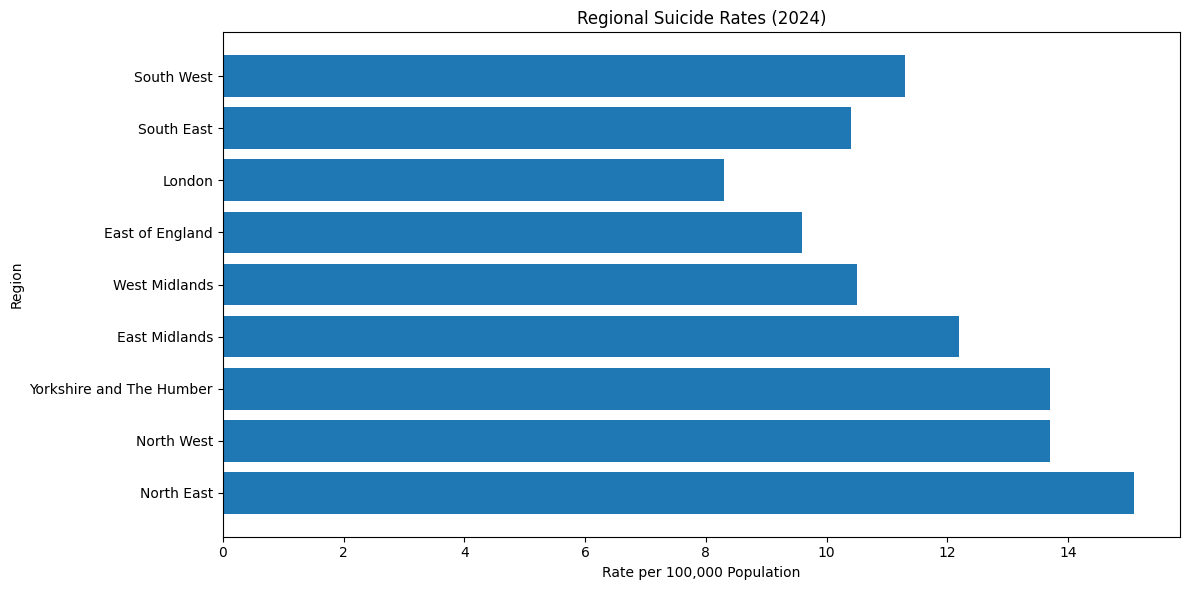

In [17]:
plt.figure(figsize=(12,6))

plt.barh(
    regions["Region"],
    regions["Rate_2024"]
)

plt.title(
    "Regional Suicide Rates (2024)"
)

plt.xlabel(
    "Rate per 100,000 Population"
)

plt.ylabel(
    "Region"
)

plt.tight_layout()

plt.show()

# KEY INSIGHTS SUMMARY

In [18]:
latest_year = trend["Year"].max()

latest_data = trend[trend["Year"] == latest_year].iloc[0]

highest_death_year = trend.loc[trend["Persons_Deaths"].idxmax()]
highest_rate_year = trend.loc[trend["Persons_Rate"].idxmax()]

summary_table = pd.DataFrame({
    "Metric": [
        "Latest Year",
        "Total Suicide Deaths",
        "Suicide Rate per 100,000",
        "Male Deaths",
        "Female Deaths",
        "Highest Death Year",
        "Highest Suicide Deaths",
        "Highest Rate Year",
        "Highest Suicide Rate"
    ],
    
    "Value": [
        latest_year,
        latest_data["Persons_Deaths"],
        latest_data["Persons_Rate"],
        latest_data["Male_Deaths"],
        latest_data["Female_Deaths"],
        highest_death_year["Year"],
        highest_death_year["Persons_Deaths"],
        highest_rate_year["Year"],
        highest_rate_year["Persons_Rate"]
    ]
})

display(summary_table)

,Metric,Value
0,Latest Year,2024.0
1,Total Suicide Deaths,6190.0
2,"Suicide Rate per 100,000",11.4
3,Male Deaths,4599.0
4,Female Deaths,1591.0
5,Highest Death Year,2024.0
6,Highest Suicide Deaths,6190.0
7,Highest Rate Year,1981.0
8,Highest Suicide Rate,14.5


# TOP REGIONS BY 2024 SUICIDE RATE

In [19]:
top_regions = regions.sort_values(
    by="Rate_2024",
    ascending=False
)

display(top_regions)

,Region,Deaths_2024,Rate_2024
5,North East,359,15.1
6,North West,916,13.7
7,Yorkshire and The Humber,680,13.7
8,East Midlands,537,12.2
13,South West,586,11.3
9,West Midlands,560,10.5
12,South East,882,10.4
10,East of England,549,9.6
11,London,648,8.3


# SAVE CLEAN DATASETS

In [20]:
trend.to_csv(
    "clean_suicide_trend_1981_2024.csv",
    index=False
)

regions.to_csv(
    "regional_suicide_rates_2024.csv",
    index=False
)

summary_table.to_csv(
    "samaritans_crisis_summary_table.csv",
    index=False
)

print("Clean datasets saved successfully.")

Clean datasets saved successfully.


# FINAL COMMENTARY

In [21]:
commentary = """
Samaritans Crisis Trends Analysis Commentary

The suicide trend data for England and Wales shows long-term variation in suicide deaths and age-standardised suicide rates between 1981 and 2024. In 2024, the dataset recorded 6,190 suicide deaths, with an age-standardised rate of 11.4 deaths per 100,000 population.

A clear gender difference is visible. Male suicide deaths remain substantially higher than female deaths. In 2024, male deaths were 4,599 compared with 1,591 female deaths, showing that men continue to represent the highest-risk group.

Regional variation is also evident in the 2024 data. The North East recorded the highest suicide rate at 15.1 per 100,000, followed by the North West and Yorkshire and The Humber. London recorded the lowest rate at 8.3 per 100,000.

Although this dataset does not contain monthly call-volume data, it provides strong public-health evidence for crisis trend analysis using official suicide statistics. The findings suggest continued need for crisis prevention, regional targeting, and male-focused mental health support interventions.
"""

print(commentary)


Samaritans Crisis Trends Analysis Commentary

The suicide trend data for England and Wales shows long-term variation in suicide deaths and age-standardised suicide rates between 1981 and 2024. In 2024, the dataset recorded 6,190 suicide deaths, with an age-standardised rate of 11.4 deaths per 100,000 population.

A clear gender difference is visible. Male suicide deaths remain substantially higher than female deaths. In 2024, male deaths were 4,599 compared with 1,591 female deaths, showing that men continue to represent the highest-risk group.

Regional variation is also evident in the 2024 data. The North East recorded the highest suicide rate at 15.1 per 100,000, followed by the North West and Yorkshire and The Humber. London recorded the lowest rate at 8.3 per 100,000.

Although this dataset does not contain monthly call-volume data, it provides strong public-health evidence for crisis trend analysis using official suicide statistics. The findings suggest continued need for crisis